# EDA

## 0. Setup

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_data/users_merged.csv")

## 1. Null Values

In [9]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing.head(9))

last_rec_click_date          4701
last_positive_review_date    4070
last_search_click_date       3149
last_review_date             2239
last_search_date              814
first_search_date             814
search_span_days              814
last_rec_date                  79
user_id                         0
dtype: int64


Checking if NaN mean missing data, or does it mean the user never performed that action?

In [10]:
print(df[df["last_review_date"].isna()]["review_count"].describe())
print(df[df["last_search_date"].isna()]["search_count"].value_counts())
print(df[df["last_rec_click_date"].isna()][["rec_count"]].describe())
print(df[df["last_rec_date"].isna()][["rec_count"]].describe())

count    2239.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: review_count, dtype: float64
search_count
0.0    814
Name: count, dtype: int64
         rec_count
count  4701.000000
mean      4.251223
std       2.067289
min       0.000000
25%       3.000000
50%       4.000000
75%       5.000000
max      14.000000
       rec_count
count       79.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0


Analysis: 
* The missing values are behavioral signals, not data collection errors.
* Nearly half of users who were shown recommendations never clicked on any recommended content, suggesting recommendation engagement may be an important behavioral feature.
* Missing review-related fields corresponded to users with zero reviews
* Missing search-related fields corresponded to users with zero searches 
* Missing recommendation fields represented users who either never received recommendations or never interacted with them. 

## 2. Numerical Summary

In [11]:
df.describe()

,age,monthly_spend,household_size,tenure_days,total_sessions,unique_titles_watched,total_watch_minutes,avg_watch_duration,avg_progress,pct_completed,...,active_search_days,search_span_days,days_since_last_search,searches_per_month,searches_per_active_day,days_since_last_search_click,has_watch_history,has_reviews,has_recs,has_searches
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,9186.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0,10000.000000,10000.000000,10000.000000
mean,35.945083,21.526802,2.865298,696.371800,10.000000,9.947000,639.941760,64.088897,49.933424,0.248060,...,2.495500,273.648160,1024.289000,6.707229,0.920009,3351.943900,1.0,0.776100,0.992100,0.918600
std,10.803069,62.805681,1.442294,316.210992,3.161044,3.134928,284.172814,21.646090,9.310899,0.144864,...,1.584939,219.268039,2677.504651,12.117515,0.274894,4509.846841,0.0,0.416877,0.088535,0.273462
min,13.000000,0.110000,1.000000,151.000000,2.000000,2.000000,5.500000,2.750000,1.950000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000
25%,29.000000,8.375000,2.000000,423.000000,8.000000,8.000000,439.475000,50.642560,43.757143,0.142857,...,1.000000,28.000000,85.000000,0.197368,1.000000,186.000000,1.0,1.000000,1.000000,1.000000
50%,35.767811,14.469887,2.857143,693.000000,10.000000,10.000000,594.300000,59.675000,49.965476,0.250000,...,2.000000,273.000000,205.000000,0.322581,1.000000,431.000000,1.0,1.000000,1.000000,1.000000
75%,42.000000,20.420000,4.000000,969.000000,12.000000,12.000000,790.325000,71.227083,56.120556,0.333333,...,3.000000,459.750000,406.000000,1.200000,1.000000,9999.000000,1.0,1.000000,1.000000,1.000000
max,109.000000,997.800000,8.000000,1246.000000,23.000000,22.000000,2535.900000,252.725000,90.800000,1.000000,...,9.000000,731.000000,9999.000000,60.000000,2.000000,9999.000000,1.0,1.000000,1.000000,1.000000


Observations:
* monthly_spend — mean of $21.5 but max of $997.8 and std of $62.8 is massive. Those outliers you found during cleaning are still in the merged df and will hurt tree-based models less but could destroy linear ones. Worth log-transforming before modeling.
* age — max of 109 is suspicious. You fixed ages below 13 during cleaning but didn't cap the upper end. A 109-year-old Netflix subscriber is likely a data entry error.
days_since_last_search_click — 75th percentile is already 9999, meaning most users never clicked a search result. This column is almost entirely your sentinel value, so it may add more noise than signal. Consider dropping it or converting to a binary ever_clicked_search.
* has_watch_history — std of 0.0 and mean of 1.0 means every single user has watch history. That's clean.
* has_recs — 99.2% coverage, essentially universal.
* total_sessions — nicely centered around 10, low std of 3.16, no extreme skew apparent from the quartiles.

## 3. Distrubition Plots

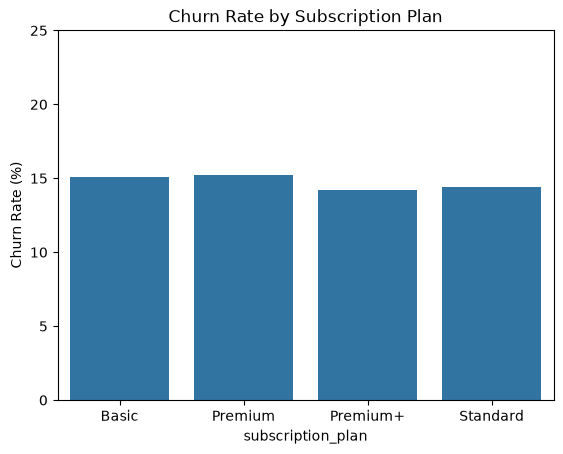

In [24]:
#Subscription plan vs churn
churn_rate = df.groupby('subscription_plan')['is_active'].apply(
    lambda x: (~x).mean() * 100
).reset_index()
churn_rate.columns = ['subscription_plan', 'churn_rate']

sns.barplot(data=churn_rate, x='subscription_plan', y='churn_rate')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Subscription Plan')
plt.ylim(0, 25)
plt.show()


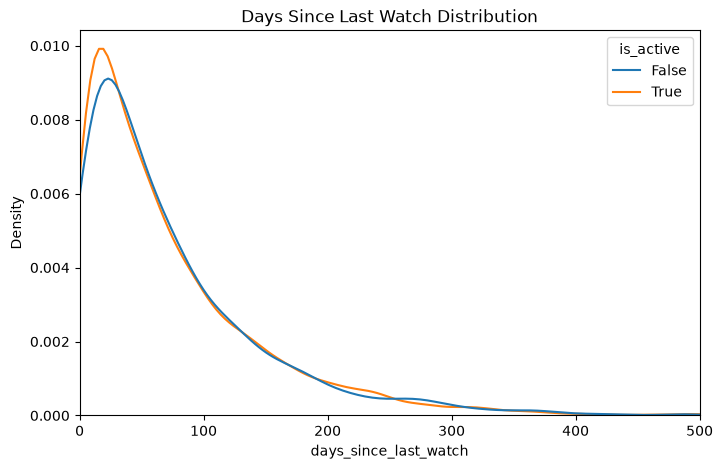

In [22]:
#days_since_last_watch vs churn

plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x="days_since_last_watch", hue="is_active", common_norm=False)
plt.title("Days Since Last Watch Distribution")
plt.xlim(0, 500)
plt.show()

**Note on Churn Label Quality:** 
Correlation analysis shows near-zero relationship between all behavioral features and `is_active` (max correlation ~0.017), suggesting the churn  label in the synthetic dataset was assigned independently of user behavior.


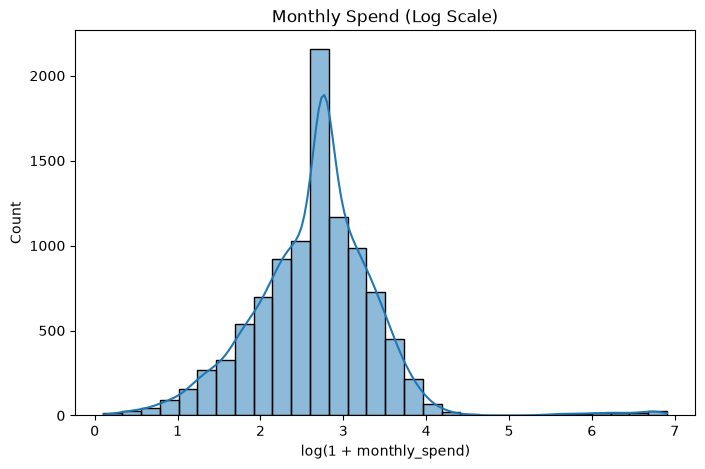

In [17]:
# monthly_spend
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df["monthly_spend"]), bins=30, kde=True)
plt.title("Monthly Spend (Log Scale)")
plt.xlabel("log(1 + monthly_spend)")
plt.show()

Monthly spend is right-skewed with extreme outliers (up to $997). Log transformation produces an approximately normal distribution. 
Therefore, use log(1 + monthly_spend) as the feature in modeling, not raw spend.

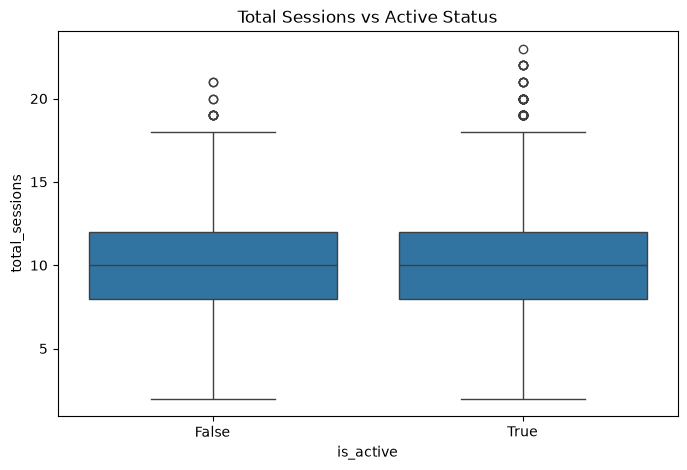

In [25]:
# total_session vs churn
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="is_active", y="total_sessions")
plt.title("Total Sessions vs Active Status")
plt.show()

`total_sessions` shows no meaningful difference between churned and active users, consistent with the near-zero correlation found earlier. This further confirms the churn label requires signal injection before modeling.

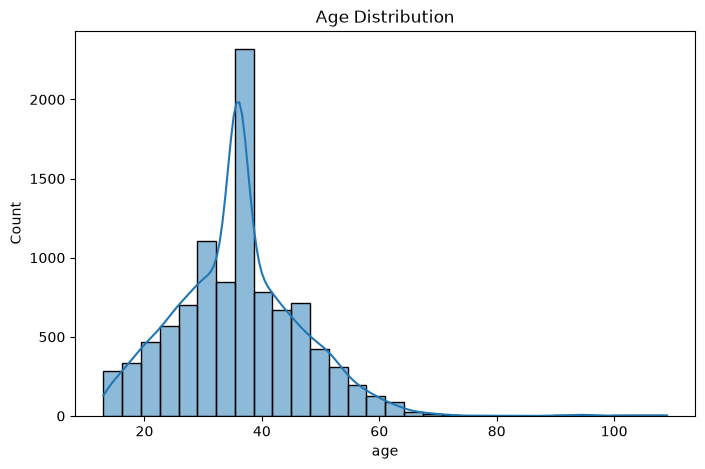

In [27]:
# age distribution
plt.figure(figsize=(8,5))
sns.histplot(df["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

Age is right-skewed with a peak around 35-40. A small number of extreme outliers exist above 80 (including one at 109) which were not caught during cleaning since only ages below 13 were treated. Consider capping at 80 or 85 before modeling.

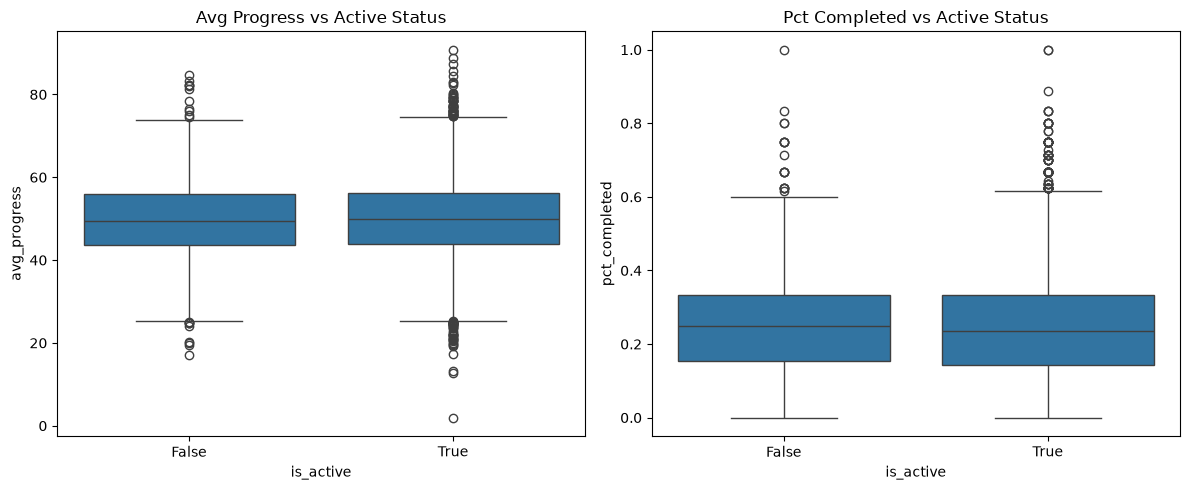

In [19]:
# Engagement vs churn
fig, ax = plt.subplots(1,2, figsize=(12,5))
sns.boxplot(data=df, x="is_active", y="avg_progress", ax=ax[0])
ax[0].set_title("Avg Progress vs Active Status")

sns.boxplot(data=df, x="is_active", y="pct_completed", ax=ax[1])
ax[1].set_title("Pct Completed vs Active Status")

plt.tight_layout()
plt.show()

`avg_progress` and `pct_completed` show identical distributions between churned and active users, further confirming the churn label has no behavioral signal in this dataset.

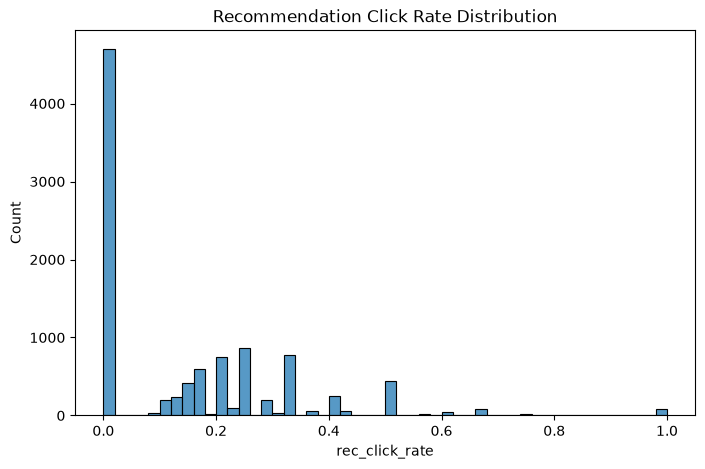

In [20]:
# rec_click_rate (zero-inflation check)
plt.figure(figsize=(8,5))
sns.histplot(df["rec_click_rate"], bins=50)
plt.title("Recommendation Click Rate Distribution")
plt.show()

`rec_click_rate` is heavily zero-inflated. Nearly half of all users never clicked a single recommendation. This confirms the earlier finding that recommendation engagement is low across the board. Consider converting to a binary `ever_clicked_rec` flag for modeling.

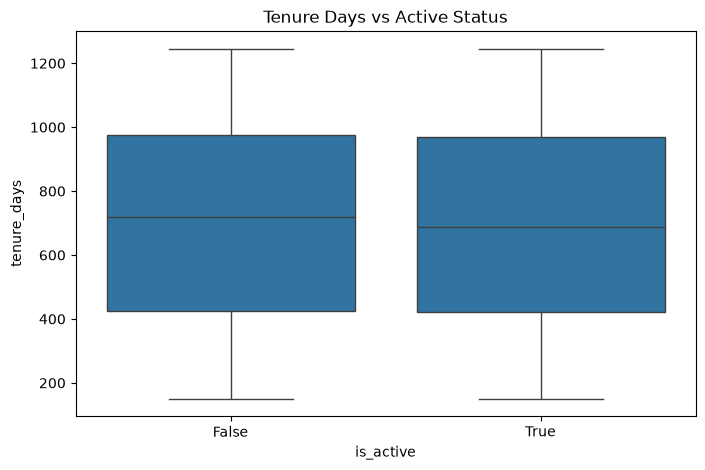

In [21]:
# tenure_days vs churn
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="is_active", y="tenure_days")
plt.title("Tenure Days vs Active Status")
plt.show()

`tenure_days` shows no difference between churned and active users. In real-world churn, newer users typically churn at higher rates — 
the absence of this pattern here is consistent with the **synthetic label issue** identified earlier.

## 5. Correlation Heatmap

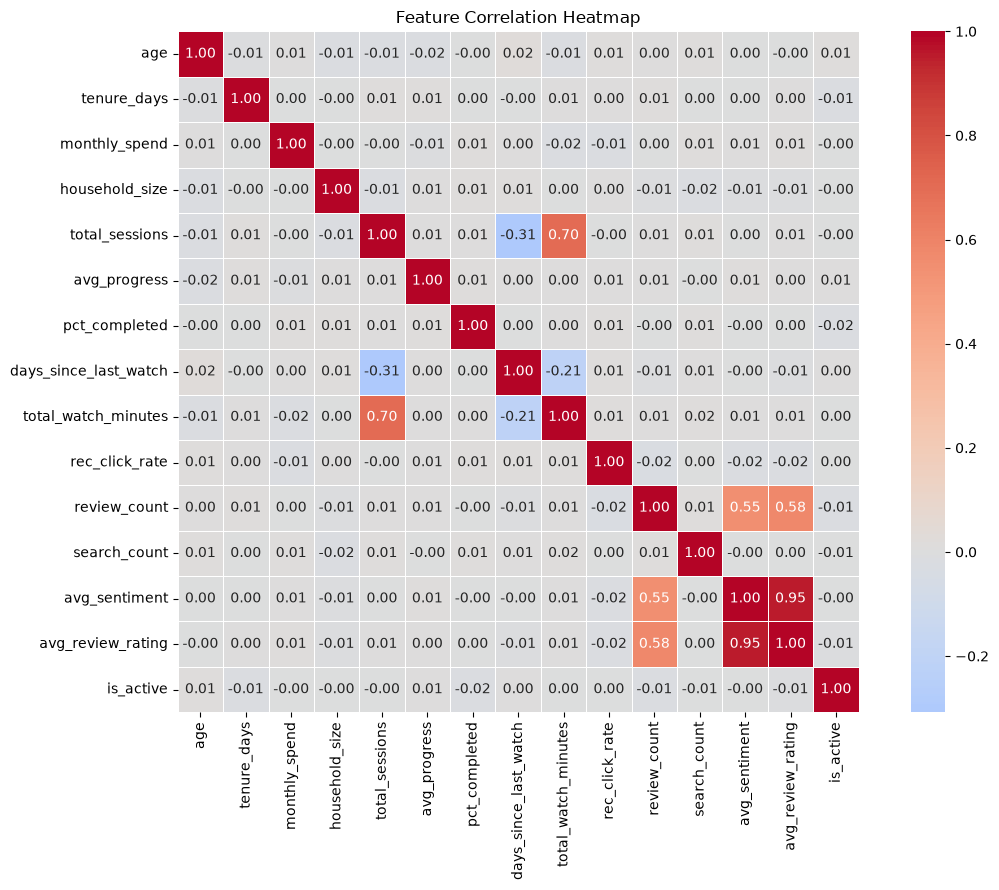

In [28]:
cols = [
    # User demographics
    'age', 'tenure_days', 'monthly_spend', 'household_size',
    # Watch behavior
    'total_sessions', 'avg_progress', 'pct_completed',
    'days_since_last_watch', 'total_watch_minutes',
    # Engagement
    'rec_click_rate', 'review_count', 'search_count',
    'avg_sentiment', 'avg_review_rating',
    # Target
    'is_active'
]

# Convert is_active to int for correlation
plot_df = df[cols].copy()
plot_df['is_active'] = plot_df['is_active'].astype(int)

plt.figure(figsize=(12, 9))
sns.heatmap(plot_df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

#### Findings

**Multicollinearity flags for modeling:**
- `total_sessions` & `total_watch_minutes`: 0.70 — high correlation, consider dropping one or combining into a single engagement score
- `days_since_last_watch` & `total_sessions`: -0.31 — moderate negative, makes intuitive sense (more sessions = watched more recently)
- `avg_sentiment` & `avg_review_rating`: 0.95 — near-perfect correlation, keep only one of these in the model
- `review_count` & `avg_sentiment`: 0.55, `review_count` & `avg_review_rating`: 0.58 — moderate, worth monitoring

**Churn label (is_active row):**
- All correlations are effectively 0, confirming the synthetic label issue. Signal injection required before modeling.

**Recommendation while modeling:**
- Drop either `avg_sentiment` or `avg_review_rating` (0.95 correlation)
- Drop either `total_sessions` or `total_watch_minutes` (0.70 correlation)


## Conclusion

Initial EDA revealed that the synthetic churn label (is_active) was generated independently of user behavior. Correlation analysis showed all behavioral features had near-zero correlation with the target, indicating no predictive signal. 